Hecho por Pedro Sánchez-Moreno Hinarejos

## Descripción del dataset


El dataset incluye entre otras, las siguientes variables:

VARIABLES DEMOGRAFICAS
male de tipo binaria: 1=Hombre, 0=Mujer
age de tipo numerica continua: edad del paciente en años
education de tipo ordinal: 1=Sin titulo, 2=Bachillerato, 3=Formacion profesional, 4=titulacion universitaria

VARIABLES DE ESTILO DE VIDA
currentsomker de tipo binaria: 1=Si, 0=No
cigsperday de tipo numerica discreta: numero de cigarrillos fumados por día

HISTORIAL MEDICO
BPMeds de tipo binaria: medicacion para la tension arterial 1=Si, 0=No
prevalentStroke ed tipo binaria: ictus previo 1=Si, 0=No
prevalentHyp de tipo binaria: hipertension diagnosticada 1=Si, 0=No
diabetes de tipo binaria: 1=Si, 0=No

MEDIDAS CLINICAS
totChol de tipo numerica continua: nivel de colesterol en sangre mg/dl
sysBP de tipo numerica continua: presion arterial sitolica mmHg
diaBP de tipo numerica continua: presion arterial diastolica mmHg
BMI de tipo numerica continua: indice de masa corporal kg/m2
heartRate de tipo numerica continua: frecuencia cardiaca en reposo latidos/min
glucose de tipo numerica continua: nivel de glucosa en sangre mg/dl

VARIABLE OBJETIVO
TenYearCHD de tipo binaria: riesgo de enfermedad coronaria a 10 años 1=Si, 0=No

Valores nulos dentro del dataset: 

glucose 388, 
education 105, 
BPMeds 53, 
totChol 50, 
cigsPerDay 29, 
BMI 19, 
heartRate 1, 

## IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

## LECTURA DE DATOS

In [2]:
df = pd.read_csv('../data/framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


En primer lugar se puede observar que el dataset tiene una cantidad de nulos en muchas de la variables que habra que limpiar para poder trabajar con el dataset correctamente. Habra que hacer una copia del dataset para poder limpiar los nulos de esa copia para mantener el original en caso de que haga falta. 

La variable objetivo de este dataset es TenYearCHD de tipo binaria: riesgo de enfermedad coronaria a 10 años, evidentemente el estudio como dice el documento con la informacion es ¿Qué características demográficas, de estilo de vida y clínicas de un paciente se asocian a un mayor riesgo de desarrollar enfermedad coronaria en los próximos 10 años?

## Hipotesis previas



INFOMRACION GENERAL DEL DATASET

In [3]:
df.shape

(4240, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


Voy a comenzar con la limpieza de datos del dataset, empezare con los nulos, y a medida que avance ire solucionando los problemas que encuentre, con la consecucion de la seleccion de variables y de categorias.

In [9]:
df.isnull().sum().sort_values(ascending=False)

glucose            388
education          105
BPMeds              53
totChol             50
cigsPerDay          29
BMI                 19
heartRate            1
male                 0
prevalentHyp         0
prevalentStroke      0
age                  0
currentSmoker        0
diaBP                0
sysBP                0
diabetes             0
TenYearCHD           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

COMENTARIOS

El dataset tiene 4240 filas y 16 columnas.
Hay valores nuloes en algunas de las variables. Habra que limpiarlas.
No parece haber duplicados.
La mayoria de columnas son binarias, aunque tambien hay numericas continuas y discretas.


ANALISIS UNIVARIBALE

Estadisticas descriptivas

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


In [16]:
df.mode()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0.0,40.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,240.0,120.0,80.0,22.19,75.0,75.0,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.54,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.91,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.48,NaN,NaN,NaN


AttributeError: module 'matplotlib' has no attribute 'show'

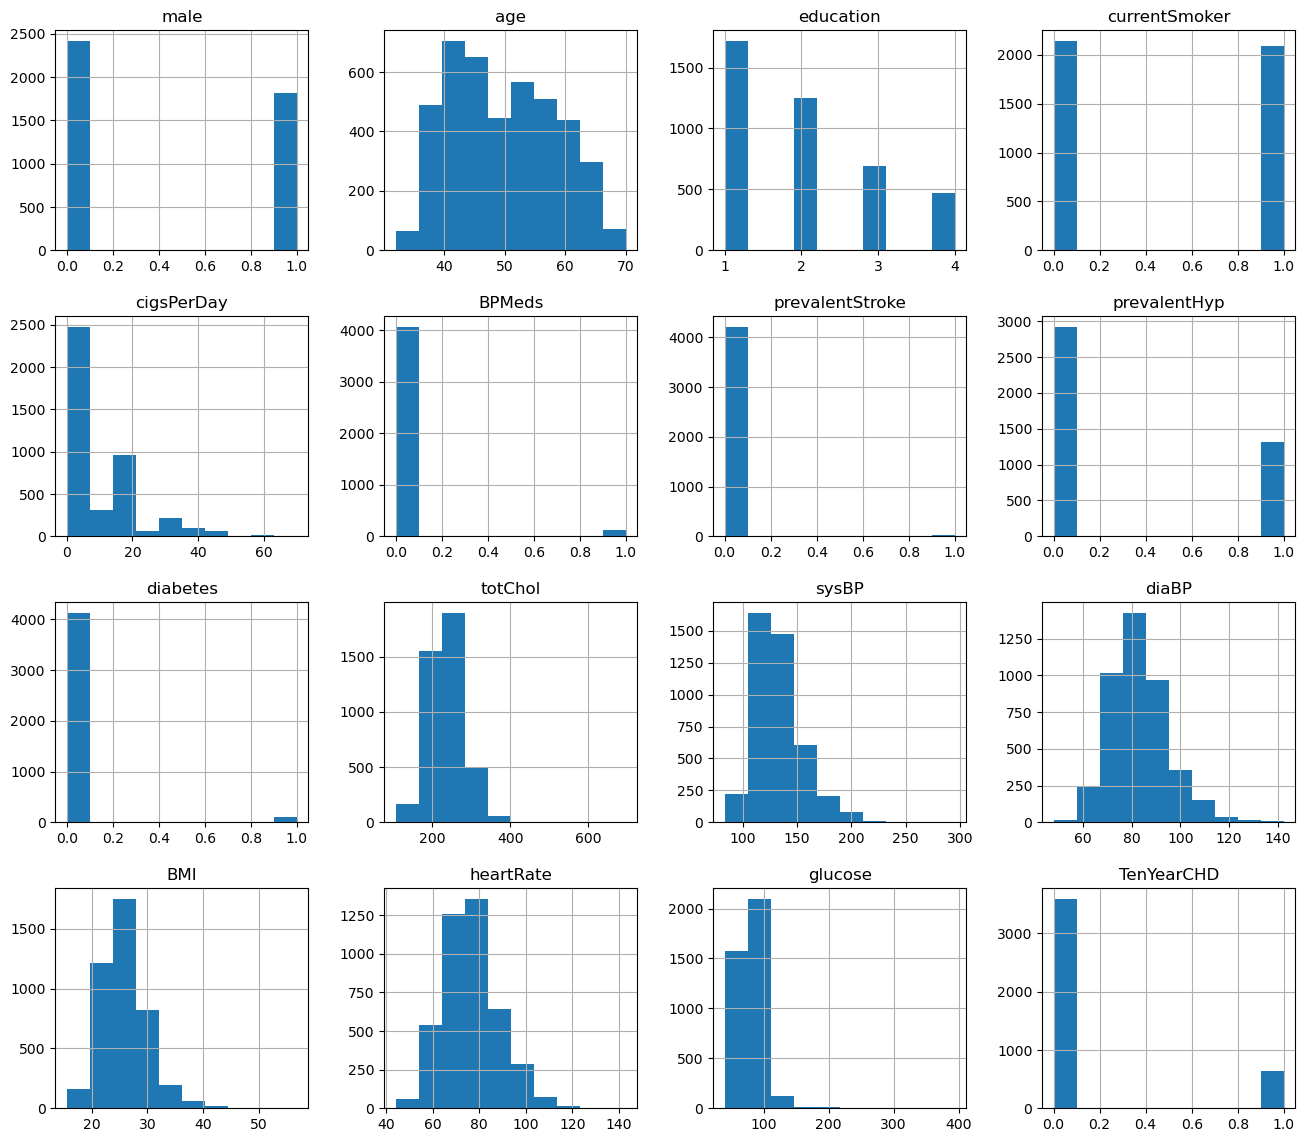

In [19]:
df.hist(figsize=(16,14))
plt.show()

COMENTARIOS
- Muchas variables son binarias, incluyenda la variable objetivo(target).
- El rango de edad va desde los 37 años aproximadamente hasta los 70 años
- Hay posibilidad de outiers en algunas variables como las siguientes: diaBP teniendo en cuenta que toda la distribucion esta concentrada en 80 y cigsperday que esta la distribucion concentrada en 0.


AttributeError: module 'matplotlib' has no attribute 'title'

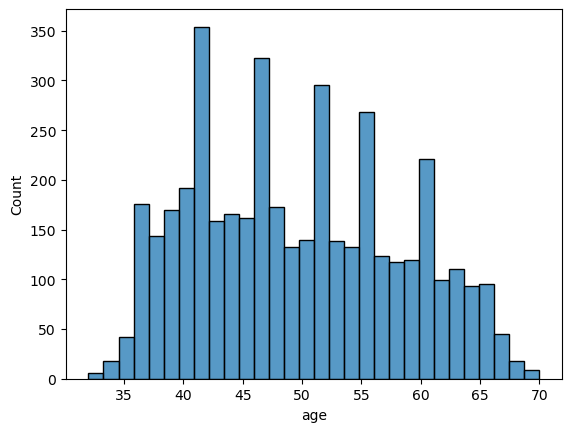

In [20]:
sns.histplot(df['age'].dropna(), bins=30)
plt.title('Rango edad')
plt.show()

AttributeError: module 'matplotlib' has no attribute 'title'

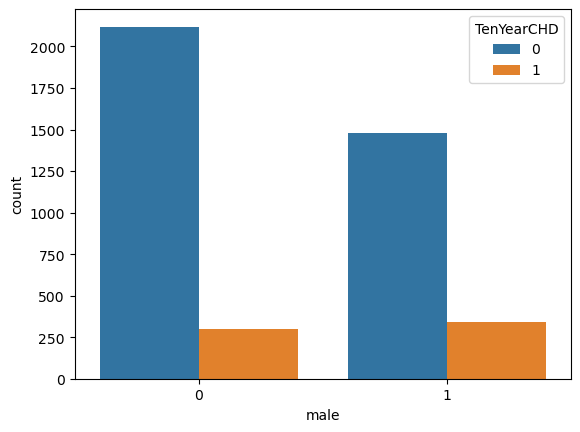

In [22]:
sns.countplot(data=df, x="male", hue="TenYearCHD")
plt.title("male vs TenYearCHD")
plt.show()

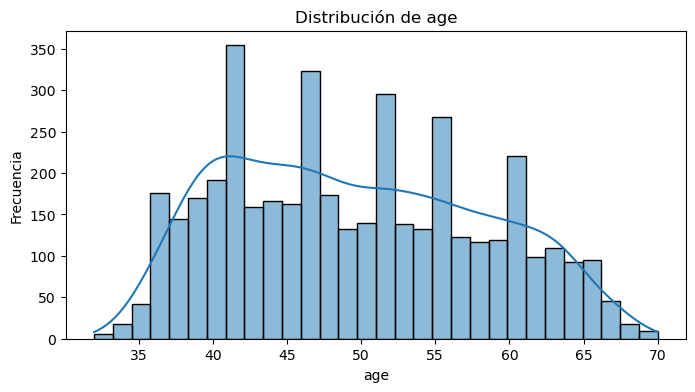

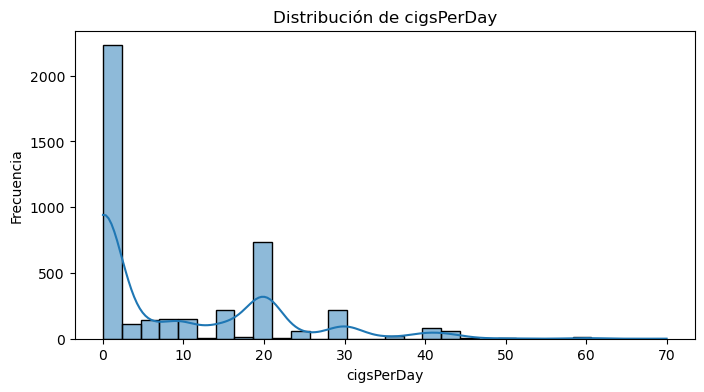

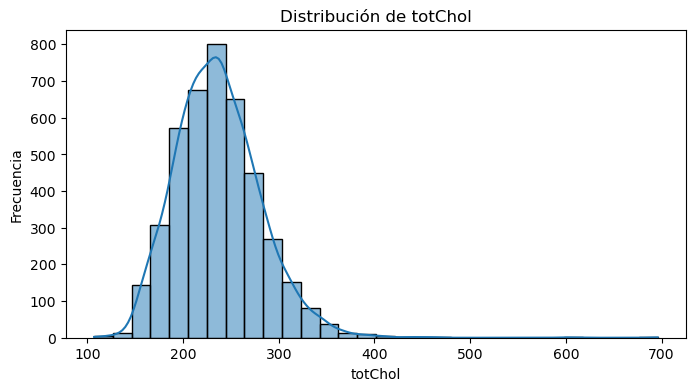

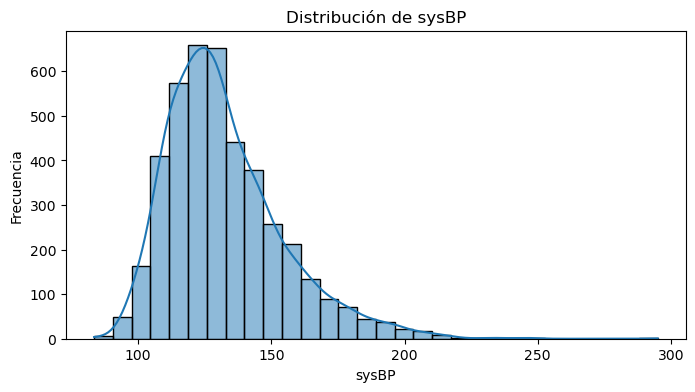

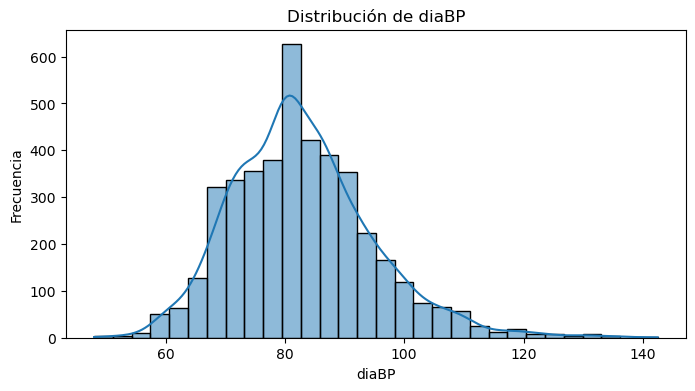

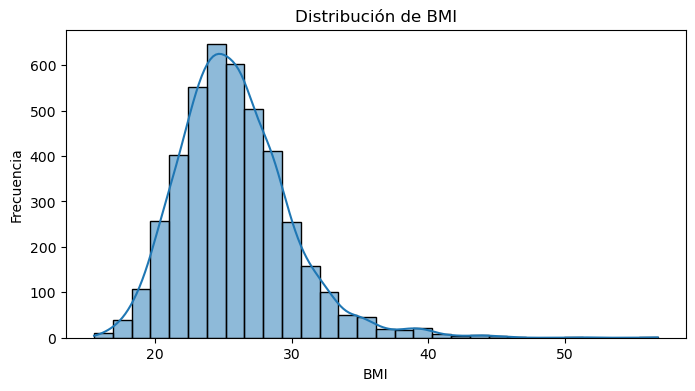

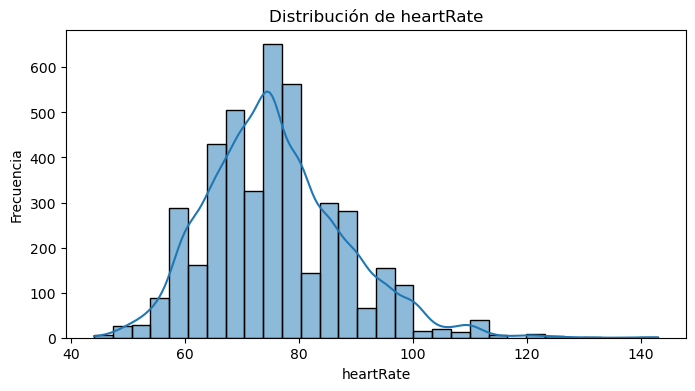

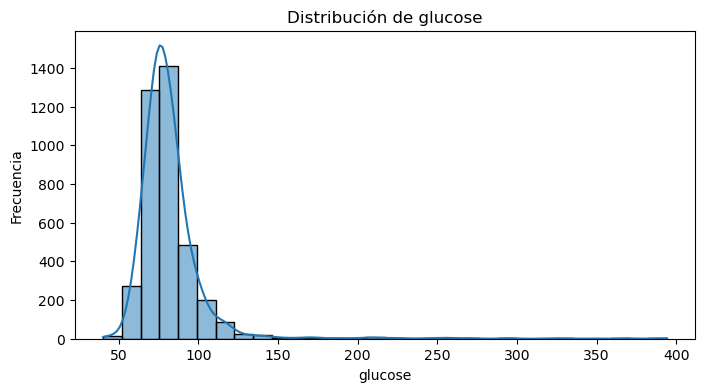

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

age parece bastante repartida entre los 30 y los 70 años, con concentración alrededor de los 49-50 años.
cigsPerDay tiene sesgo a la derecha, porque muchos pacientes tienen valor 0 y unos pocos fuman bastante.
totChol, sysBP y glucose parecen tener algunos valores altos que podrían ser atípicos.
BMI y heartRate están más concentradas, aunque también presentan cierta dispersión.

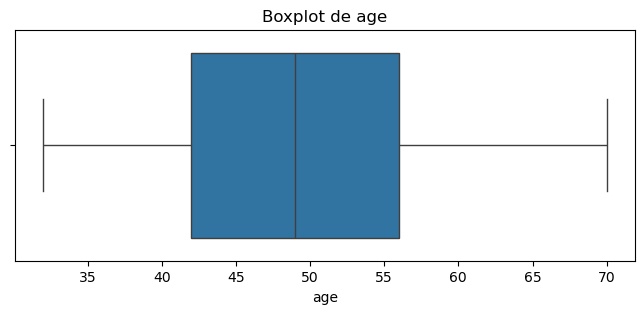

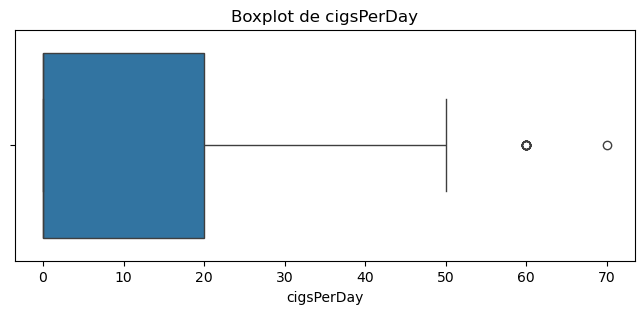

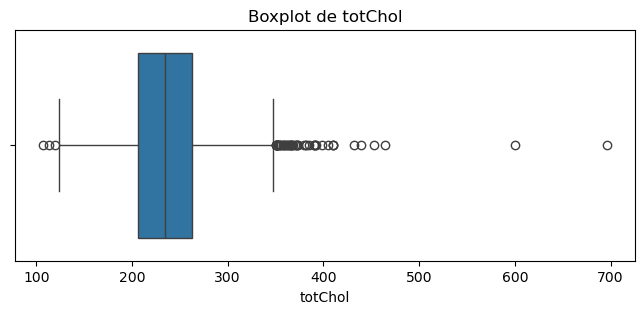

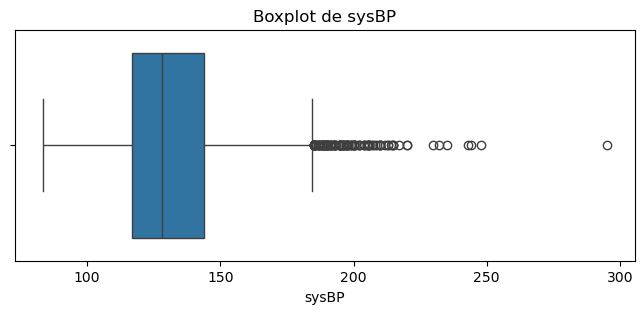

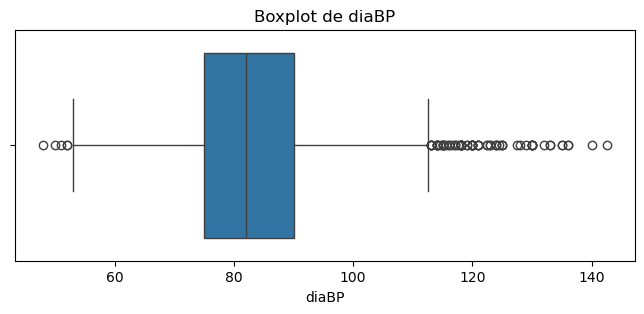

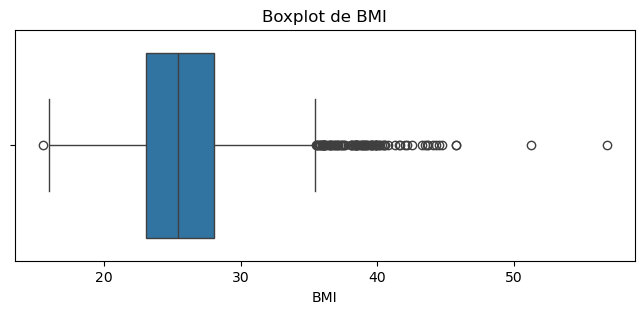

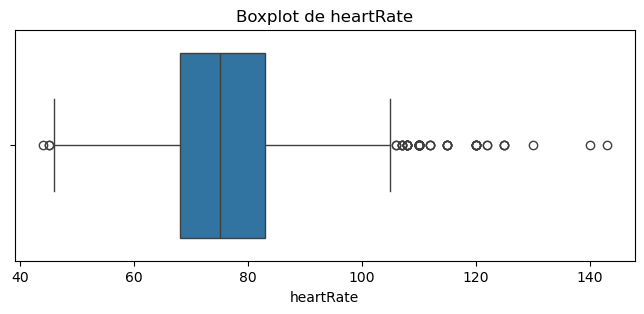

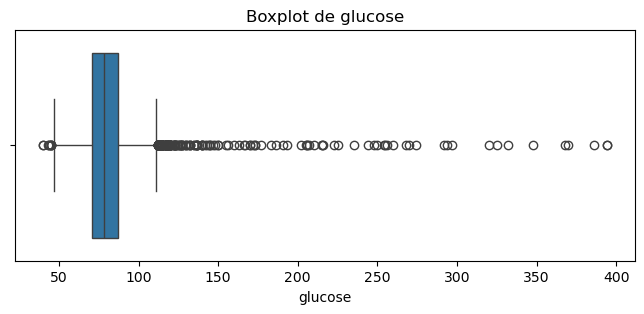

In [26]:
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

En totChol, sysBP, diaBP y glucose se ven varios valores extremos.
BMI también presenta algunos outliers, aunque no tan exagerados como otras variables.
En cigsPerDay el boxplot muestra claramente mucha concentración en valores bajos y algunos fumadores con consumos muy altos.
Esto sugiere que hay variables con asimetría y posibles outliers que conviene comentar antes del análisis bivariable.

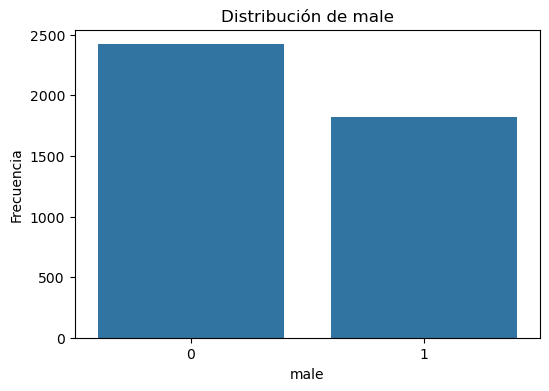

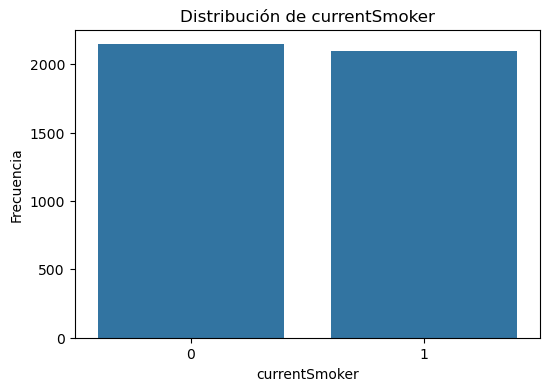

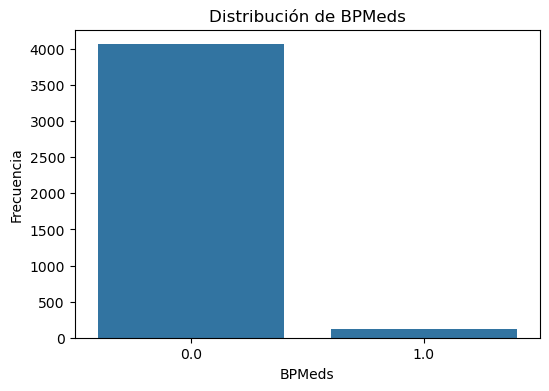

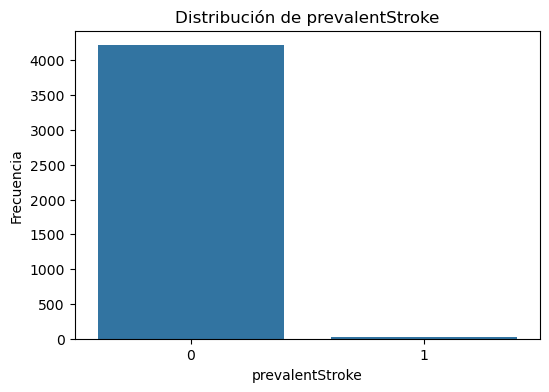

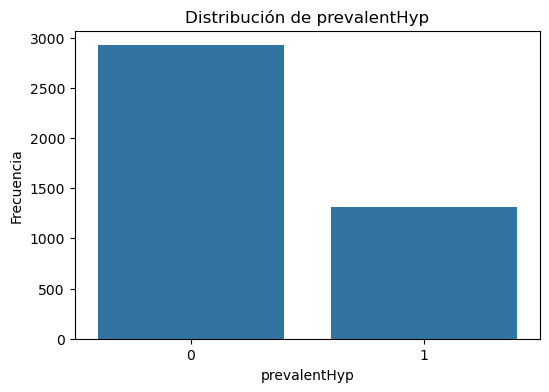

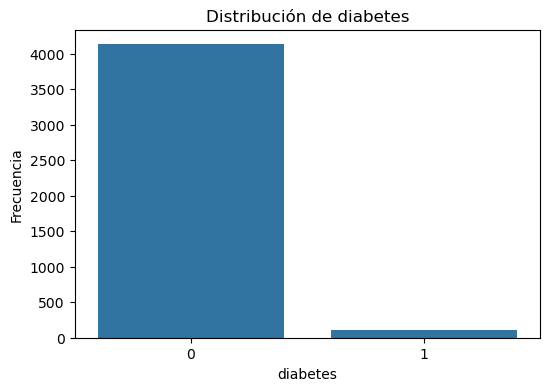

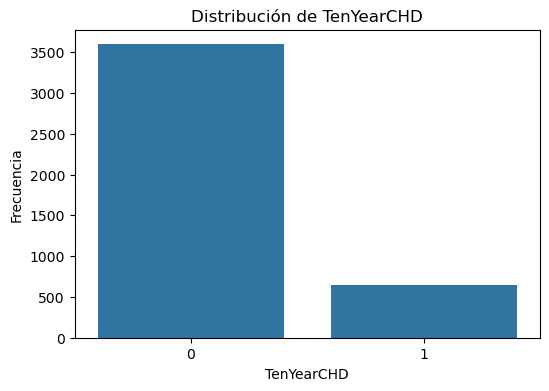

In [27]:
bin_cols = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD"]

for col in bin_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

En male hay algo más de mujeres que de hombres.
currentSmoker está bastante equilibrada entre fumadores y no fumadores.
BPMeds, prevalentStroke y diabetes están muy desbalanceadas hacia el valor 0, así que hay pocos casos positivos.
prevalentHyp tiene más presencia que otras variables clínicas binarias, aunque sigue predominando el valor 0.
La variable objetivo TenYearCHD también está desbalanceada: hay bastantes más pacientes que no desarrollan enfermedad coronaria que pacientes que sí.

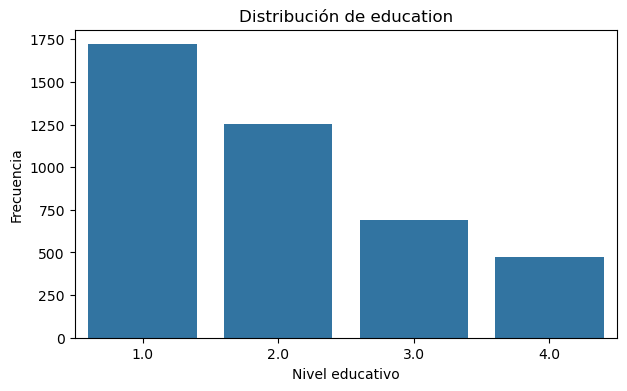

In [28]:
plt.figure(figsize=(7,4))
sns.countplot(x=df["education"])
plt.title("Distribución de education")
plt.xlabel("Nivel educativo")
plt.ylabel("Frecuencia")
plt.show()

Los niveles educativos más frecuentes parecen ser los más bajos o intermedios.
Los niveles altos de educación son menos numerosos.
Además, esta variable tiene algunos nulos, así que conviene comentarlo antes de seguir con el análisis.

COMENTARIOS DEL ANALISIS UNIVARIABLE

- La edad media está alrededor de 49,6 años y la mediana en 49, así que la muestra está bastante centrada en edades medias.
- En cigsPerDay la mediana es 0, lo que indica que al menos la mitad de los pacientes no fuma actualmente o fuma muy poco.
- El colesterol total (totChol) tiene una media de aproximadamente 236,7 y alcanza valores muy altos, hasta 696, lo que refuerza la presencia de outliers.
- La presión sistólica (sysBP) tiene una media cercana a 132,4 y llega hasta 295, así que también hay valores muy extremos.
- En male hay alrededor de 57,1 % mujeres y 42,9 % hombres.
- En currentSmoker el reparto está casi equilibrado: aproximadamente 50,6 % no fumadores frente a 49,4 % fumadores.
- En TenYearCHD el 84,8 % no desarrolla enfermedad coronaria a 10 años y el 15,2 % sí, por lo que la variable objetivo está desbalanceada.
En education, la categoría más frecuente es la 1, con alrededor del 40,6 % de los casos.

## CORRELACION ENTRE VARIABLES

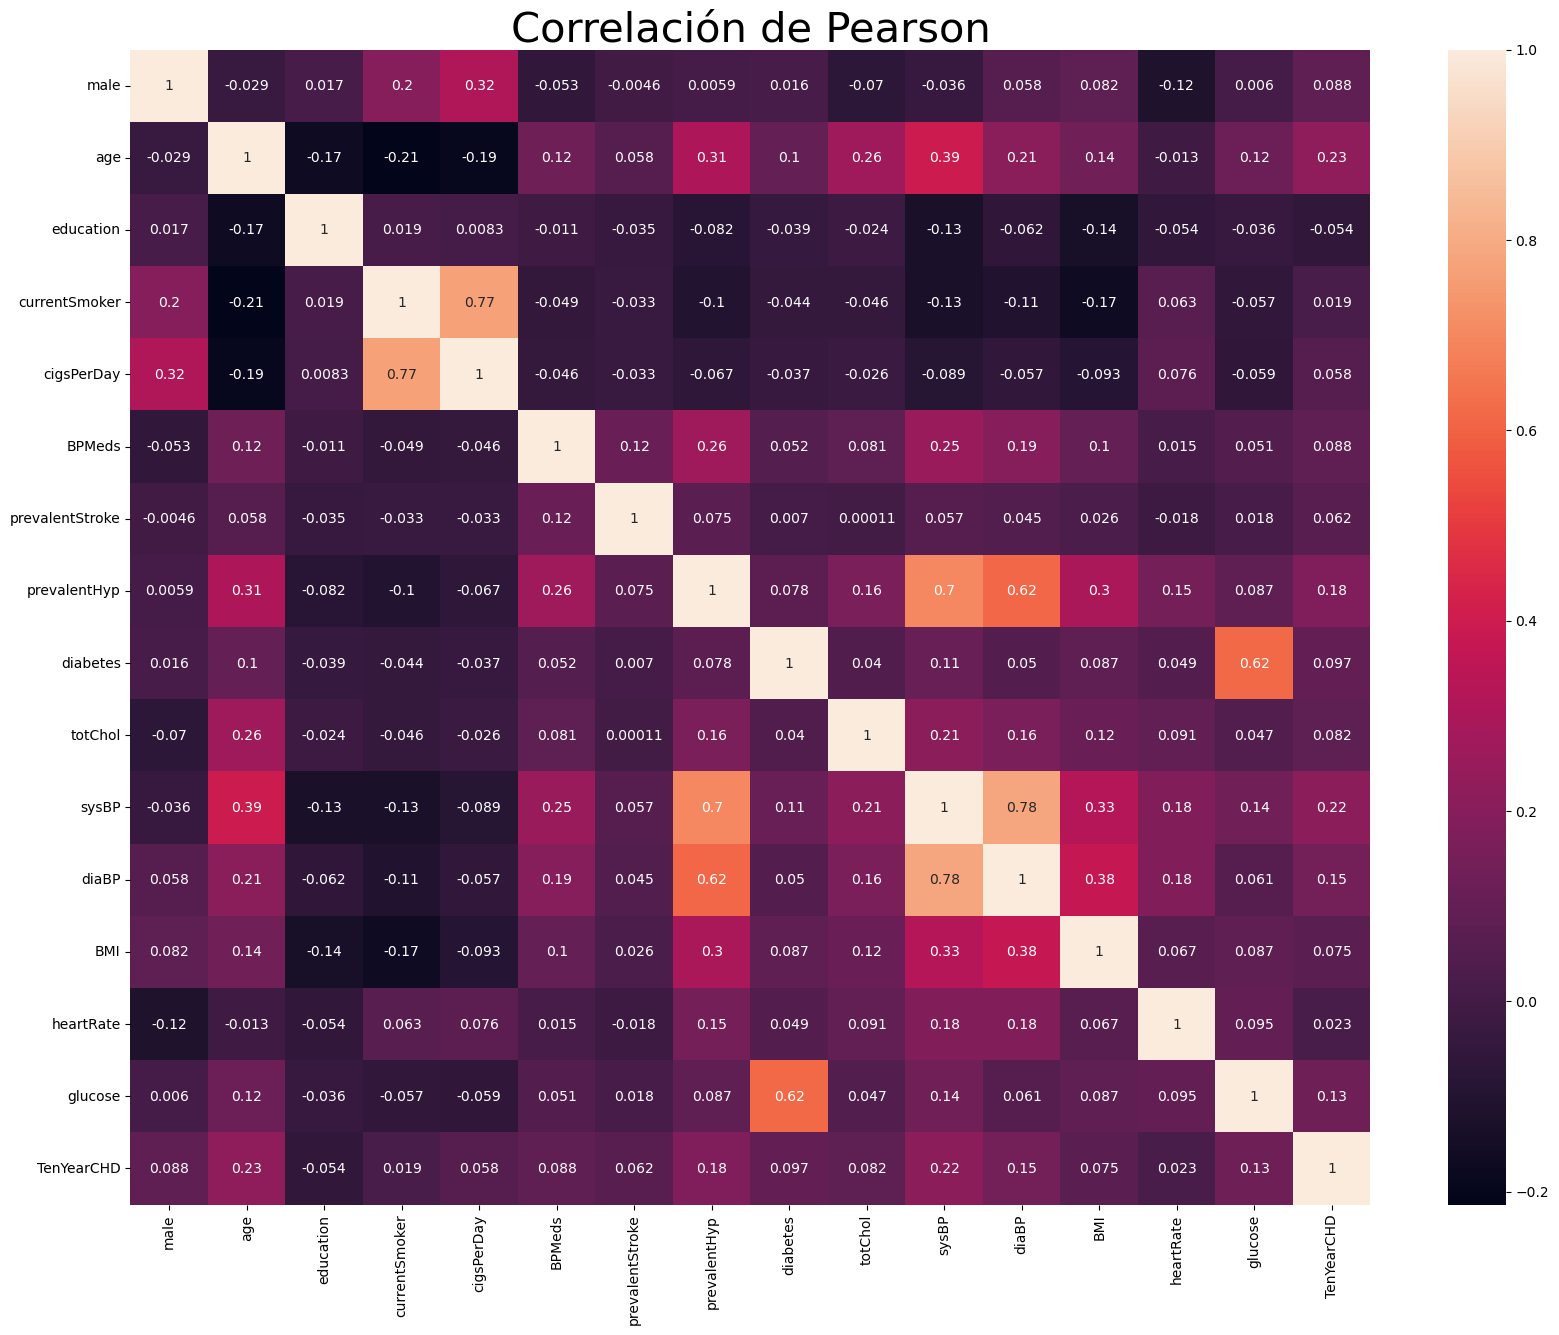

In [30]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(method='pearson'),
            annot=True)
plt.title("Correlación de Pearson", fontsize =30)
plt.show()

## ANALISIS BIVARIABLE CON TenYearCHD

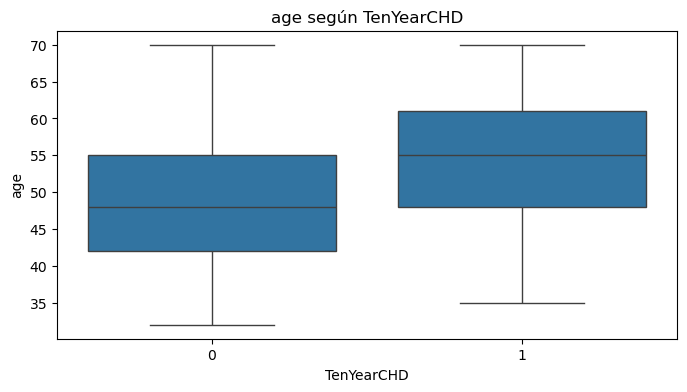

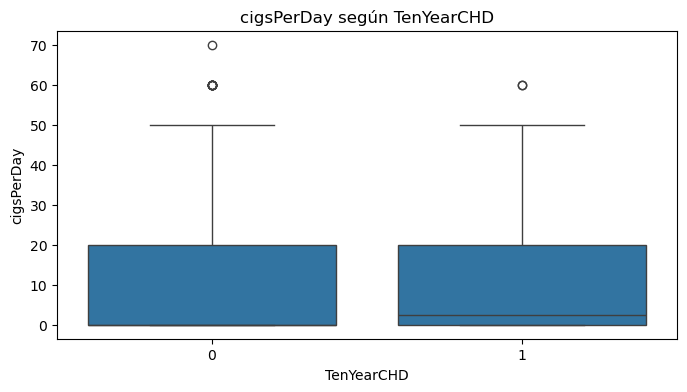

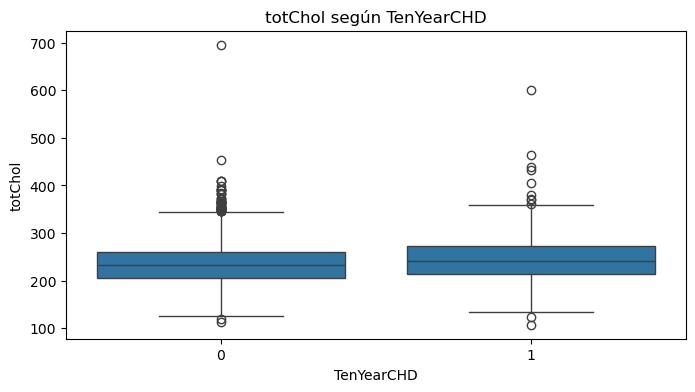

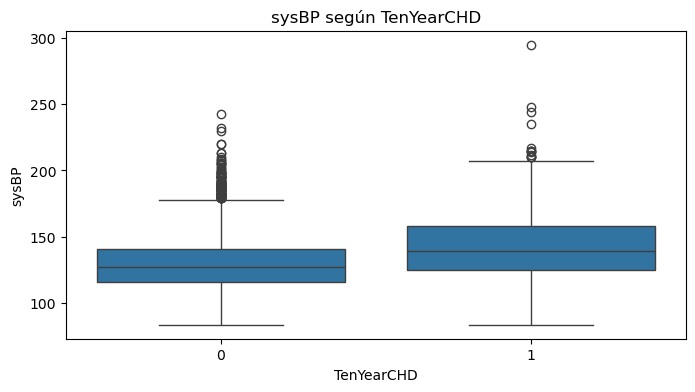

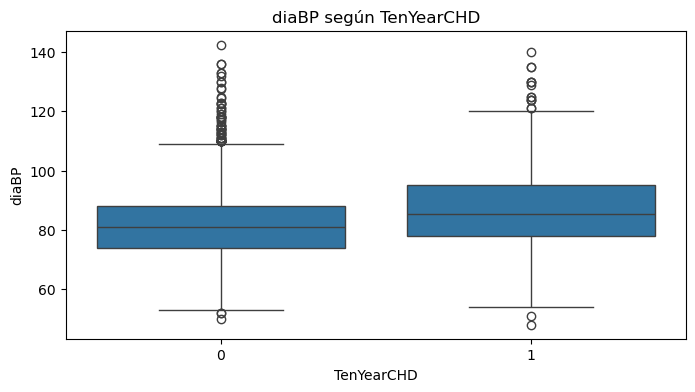

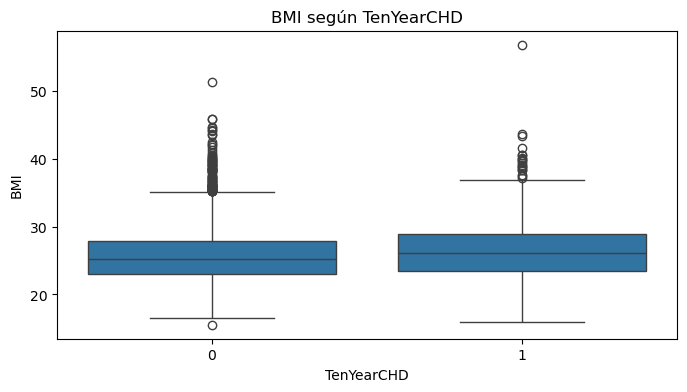

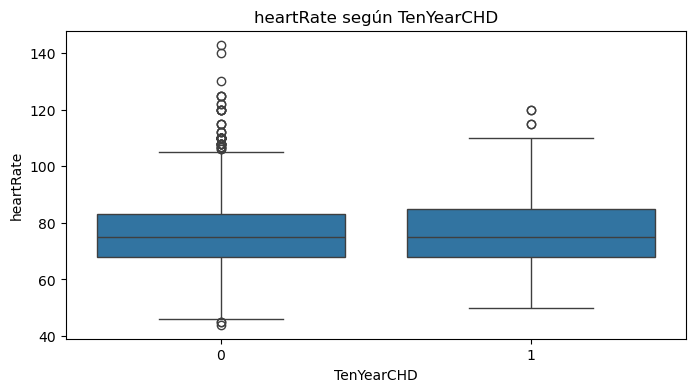

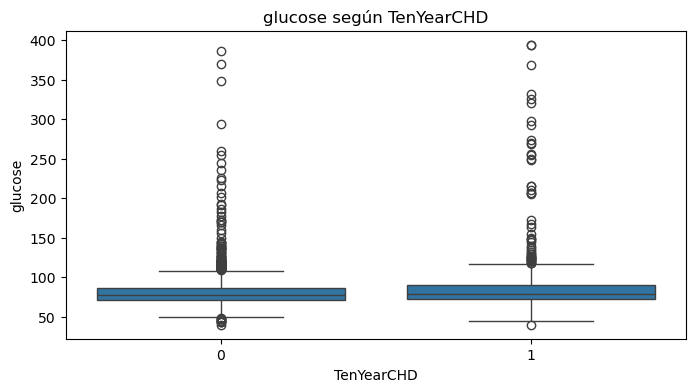

In [31]:
num_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x="TenYearCHD", y=col)
    plt.title(f"{col} según TenYearCHD")
    plt.xlabel("TenYearCHD")
    plt.ylabel(col)
    plt.show()

- En age suele verse que los pacientes con TenYearCHD = 1 tienden a ser mayores.
- En sysBP y diaBP normalmente el grupo con enfermedad presenta medianas más altas.
- En glucose y totChol también puede observarse una tendencia a valores mayores en quienes desarrollan enfermedad, aunque con dispersión.
- En BMI y heartRate las diferencias suelen ser menos claras.
- En cigsPerDay puede haber algo de diferencia, pero no siempre se separa tan bien visualmente.

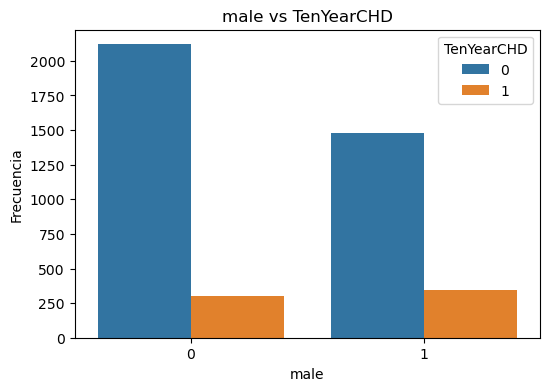

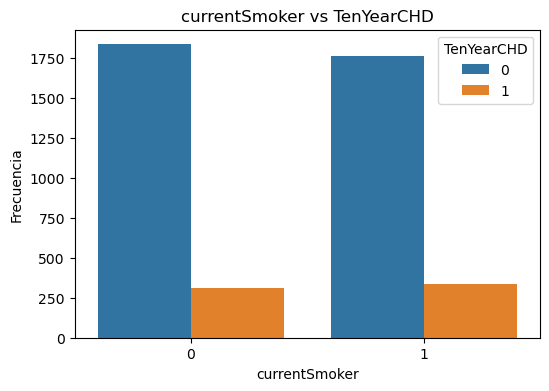

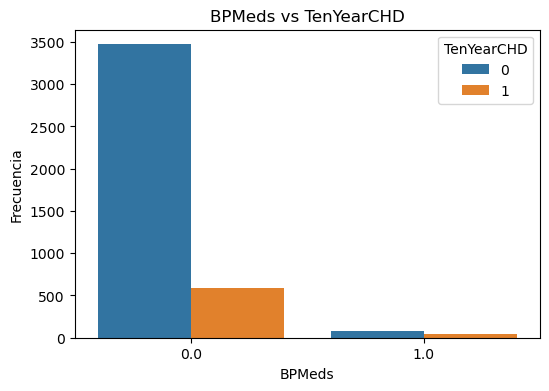

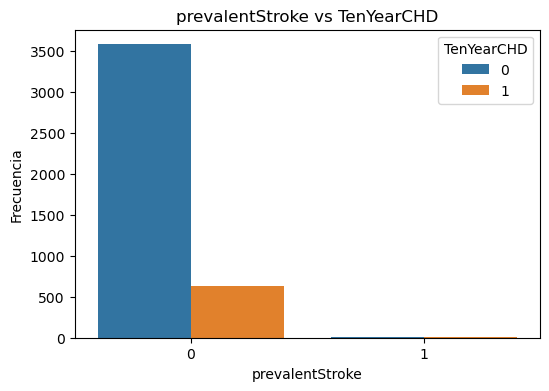

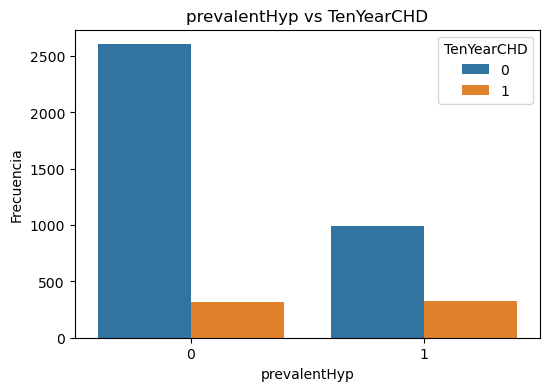

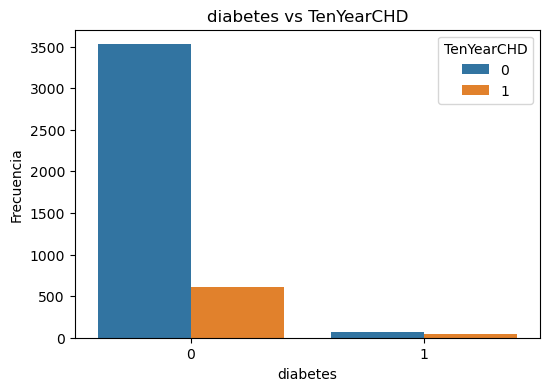

In [32]:
bin_cols = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"]

for col in bin_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="TenYearCHD")
    plt.title(f"{col} vs TenYearCHD")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

- En male, suele observarse una proporción mayor de TenYearCHD = 1 en hombres que en mujeres.
- En prevalentHyp y diabetes, la proporción de enfermedad suele ser claramente superior en el grupo 1.
- En currentSmoker la diferencia existe, pero a veces no es tan facil de identificar.
- En BPMeds puede aparecer una proporción elevada en el grupo que toma medicación, aunque también influye que esos pacientes ya parten de peor perfil clínico.
- En prevalentStroke hay pocos casos, así que aunque pueda parecer que hay diferencia, conviene comentarlo con prudencia.

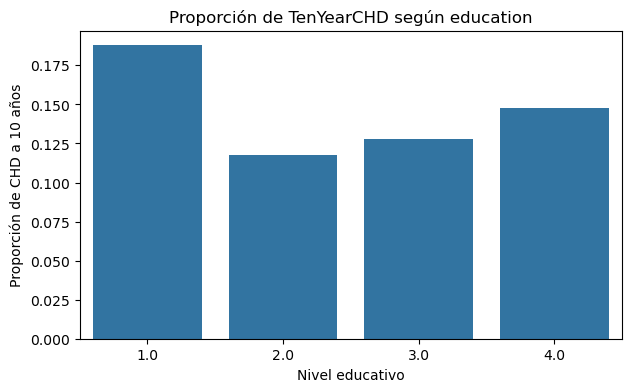

In [33]:
temp = df.groupby("education", observed=False)["TenYearCHD"].mean().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=temp, x="education", y="TenYearCHD")
plt.title("Proporción de TenYearCHD según education")
plt.xlabel("Nivel educativo")
plt.ylabel("Proporción de CHD a 10 años")
plt.show()

Los niveles educativos más bajos parecen concentrar una proporción algo mayor de TenYearCHD.

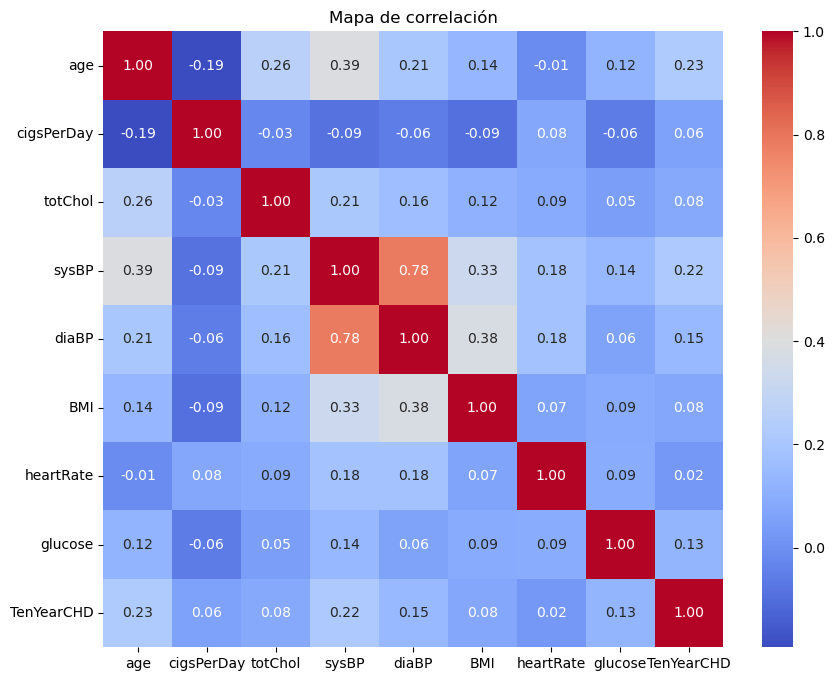

In [34]:
plt.figure(figsize=(10,8))
corr = df[num_cols + ["TenYearCHD"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlación")
plt.show()

- sysBP y diaBP tienen correlación alta.
- age puede correlacionar moderadamente con presión arterial.
- TenYearCHD normalmente muestra correlaciones positivas, pero no muy altas, con age, sysBP y alguna otra variable.
- Eso dice que ninguna variable por sí sola totalmente explica la target.

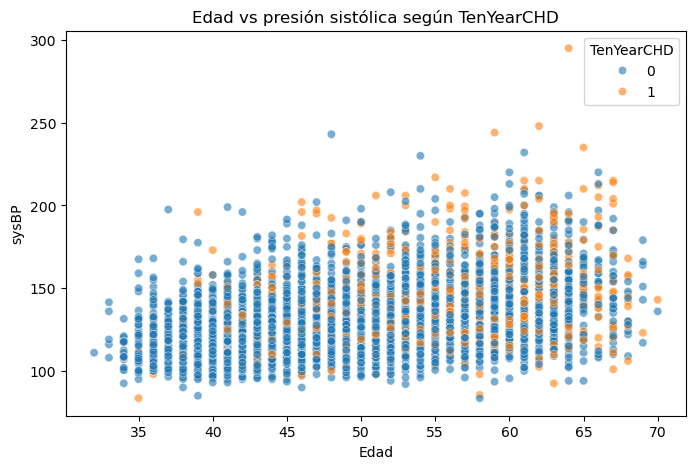

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="sysBP", hue="TenYearCHD", alpha=0.6)
plt.title("Edad vs presión sistólica según TenYearCHD")
plt.xlabel("Edad")
plt.ylabel("sysBP")
plt.show()

Gráfico hecho por IA. Busca una relacion entre la presion sistolica y la edad. Para ver si los casos positivos se concentran más en edades altas y presión alta. Hay una relación que es relevante.

El análisis bivariable vale para ver que algunas variables parecen estar más relacionadas con TenYearCHD que otras. La edad, la presión arterial y ciertas variables clínicas como hipertensión previa o diabetes muestran relaciones más claras con el riesgo de enfermedad coronaria a 10 años. En cambio, otras variables como el IMC o la frecuencia cardíaca no son tan diferentes o tan visuales en los gráficos. Además, el mapa de correlación indica que algunas variables están relacionadas entre sí, por lo que conviene interpretar los resultados teniendo en cuenta que el riesgo cardiovascular depende de varias variables a la vez.